# XGBoost xG Model

Trains and evaluates an XGBoost expected-goals classifier on StatsBomb open data.

Champions League 2018/19 is held out entirely as a test set — never used to fit the
preprocessor, tune hyperparameters, or run cross-validation — so the final evaluation
reflects genuine generalisation to an unseen competition, not just CV performance on
the same folds used to select hyperparameters.

**Pipeline summary:**
1. Load data, engineer features, and split off Champions League 2018/19 as a held-out test set
2. Preprocess — encode categoricals, impute freeze-frame missingness (fit on training shots only)
3. Tune hyperparameters with Optuna (stratified 5-fold CV on training shots, log-loss objective)
4. Final evaluation — training-CV metrics vs true held-out test metrics (AUC, log-loss, Brier score)
5. Calibration curve (held-out test)
6. xG distribution and match-level xG vs goals (held-out test)
7. SHAP feature importance (training shots)
8. Results summary

In [15]:
%load_ext autoreload
%autoreload 2

import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from statsbombpy import sb

from src.features import create_xg_features

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
os.makedirs('../outputs', exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Loading and Feature Engineering

In [46]:
COMPETITIONS = [
    {'competition_id': 11, 'season_id': 27,  'label': 'La Liga 2015/16'},
    {'competition_id': 16, 'season_id': 4,   'label': 'Champions League 2018/19'},
    {'competition_id': 2,  'season_id': 27,  'label': 'Premier League 2015/16'},
    {'competition_id': 43, 'season_id': 106, 'label': 'World Cup 2022'},
    {'competition_id': 12, 'season_id': 27,  'label': 'Serie A 2015/16'},
]

# Held out entirely from preprocessing fits, hyperparameter tuning, and CV —
# used only as a final, untouched test set to check generalisation to an
# unseen competition, rather than relying solely on CV metrics that share
# folds with the hyperparameter search.
HOLDOUT_LABEL = 'Serie A 2015/16'

def load_competition(competition_id, season_id):
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    events = pd.concat(
        [sb.events(match_id=mid).assign(match_id=mid) for mid in matches['match_id']],
        ignore_index=True,
    )
    return matches['match_id'].tolist(), events

all_events = []
match_id_to_label = {}
for comp in COMPETITIONS:
    print(f"Loading {comp['label']}…")
    match_ids, events = load_competition(comp['competition_id'], comp['season_id'])
    for mid in match_ids:
        match_id_to_label[mid] = comp['label']
    all_events.append(events)

events_df = pd.concat(all_events, ignore_index=True)
xg_df = create_xg_features(events_df)

# Penalties are excluded — their fixed location and high base rate warrant a separate model.
shots = xg_df[xg_df['is_penalty'] == 0].copy().reset_index(drop=True)
shots['competition_label'] = shots['match_id'].map(match_id_to_label)

is_holdout = shots['competition_label'] == HOLDOUT_LABEL
shots_train = shots[~is_holdout].reset_index(drop=True)
shots_test = shots[is_holdout].reset_index(drop=True)

train_labels = ', '.join(c['label'] for c in COMPETITIONS if c['label'] != HOLDOUT_LABEL)
print(f"\nTotal shots (excl. penalties): {len(shots):,}")
print(f"  Train ({train_labels}): {len(shots_train):,} shots, "
      f"{shots_train['is_goal'].mean():.1%} goal rate")
print(f"  Held-out test ({HOLDOUT_LABEL}): {len(shots_test):,} shots, "
      f"{shots_test['is_goal'].mean():.1%} goal rate")

Loading La Liga 2015/16…
Loading Champions League 2018/19…
Loading Premier League 2015/16…
Loading World Cup 2022…
Loading Serie A 2015/16…

Total shots (excl. penalties): 30,224
  Train (La Liga 2015/16, Champions League 2018/19, Premier League 2015/16, World Cup 2022): 20,347 shots, 9.9% goal rate
  Held-out test (Serie A 2015/16): 9,877 shots, 8.7% goal rate


## 2. Preprocessing

In [47]:
CATEGORICAL_FEATURES = ['shot_body_part', 'shot_technique', 'previous_event_type']

NUMERIC_FEATURES = [
    'distance_to_goal', 'shot_angle', 'centrality',
    'in_penalty_area', 'in_six_yard_box',
    'shot_first_time', 'shot_under_pressure',
    'num_defenders_in_frame', 'num_teammates_in_frame',
    'distance_to_nearest_defender', 'num_defenders_between_shot_and_goal',
    'goalkeeper_distance_to_goal', 'goalkeeper_distance_to_shooter',
    'previous_event_was_pass', 'previous_event_was_carry',
    'previous_event_same_team', 'previous_event_distance',
    'is_late_game', 'is_extra_time',
]

TARGET = 'is_goal'

preprocessor = ColumnTransformer([
    # Freeze-frame features have ~40% missingness; median imputation is deliberate
    # since their distribution is skewed (most shots have 0 defenders in lane).
    ('num', SimpleImputer(strategy='median'), NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL_FEATURES),
], remainder='drop')

# Only training-competition shots are used to fit the preprocessor, tune
# hyperparameters, and run CV. The held-out test set is transformed later
# with the fitted preprocessor but never used to fit anything.
X = shots_train[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = shots_train[TARGET].values

X_test = shots_test[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = shots_test[TARGET].values

# Dry run to confirm preprocessing works and check output shape.
X_transformed = preprocessor.fit_transform(X)
print(f"Feature matrix shape (train): {X_transformed.shape}")

ohe_feature_names = (
    preprocessor.named_transformers_['cat']['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
ALL_FEATURE_NAMES = NUMERIC_FEATURES + ohe_feature_names
print(f"Total features after encoding: {len(ALL_FEATURE_NAMES)}")

Feature matrix shape (train): (20347, 54)
Total features after encoding: 54


## 3. Hyperparameter Tuning (Optuna)

In [61]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42,
        'n_jobs': -1,
    }
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', xgb.XGBClassifier(**params)),
    ])
    fold_losses = []
    for train_idx, val_idx in CV.split(X, y):
        model.fit(X.iloc[train_idx], y[train_idx])
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        fold_losses.append(log_loss(y[val_idx], proba))
    return np.mean(fold_losses)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest log-loss: {study.best_value:.4f}\n")

# Search-space bounds are read back from Optuna's own trial distributions
# (not re-declared) so this table can't drift out of sync with objective().
tuning_summary = pd.DataFrame([
    {'Parameter': name, 'Min': dist.low, 'Max': dist.high, 'Best': study.best_params[name]}
    for name, dist in study.best_trial.distributions.items()
]).set_index('Parameter')
print("Hyperparameter search space vs. selected value:")
print(tuning_summary.to_string())

  0%|          | 0/50 [00:00<?, ?it/s]


Best log-loss: 0.2585

Hyperparameter search space vs. selected value:
                       Min     Max        Best
Parameter                                     
n_estimators      200.0000  1000.0  600.000000
max_depth           3.0000     7.0    5.000000
learning_rate       0.0100     0.2    0.010014
subsample           0.6000     1.0    0.734814
colsample_bytree    0.5000     1.0    0.565098
min_child_weight    1.0000    10.0    2.000000
reg_alpha           0.0001    10.0    0.036078
reg_lambda          0.0001    10.0    0.000350


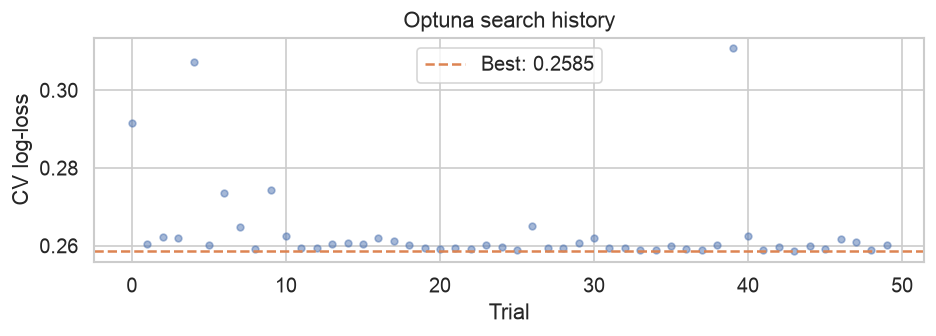

In [49]:
# Optuna optimisation history
fig, ax = plt.subplots(figsize=(8, 3))
trials_df = study.trials_dataframe()
ax.plot(trials_df['number'], trials_df['value'], 'o', alpha=0.5, ms=4, color='#4C72B0')
ax.axhline(study.best_value, color='#DD8452', linewidth=1.5, linestyle='--', label=f'Best: {study.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('CV log-loss')
ax.set_title('Optuna search history')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Final Evaluation — Training CV vs Held-Out Test

The training-CV metrics reuse the same folds used during hyperparameter tuning, so they
carry a mild optimistic bias (the search saw all 5 folds' validation performance across
50 trials). The held-out test metrics come from Champions League 2018/19, a competition
never touched during tuning or CV, and are the more trustworthy estimate of real
generalisation. All later sections (calibration, xG distribution) use the held-out test
predictions.

In [50]:
best_params = {
    **study.best_params,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'random_state': 42,
    'n_jobs': -1,
}

final_model = Pipeline([
    ('pre', preprocessor),
    ('clf', xgb.XGBClassifier(**best_params)),
])

# Training-CV probabilities — out-of-fold, but hyperparameters were selected
# using these same folds, so this remains a mildly optimistic estimate.
oof_proba = cross_val_predict(final_model, X, y, cv=CV, method='predict_proba')[:, 1]

train_cv_metrics = {
    'ROC-AUC':     roc_auc_score(y, oof_proba),
    'Log-loss':    log_loss(y, oof_proba),
    'Brier score': brier_score_loss(y, oof_proba),
}

# Fit on all training-competition shots, then predict on the untouched
# Champions League 2018/19 held-out set — a genuine test of generalisation.
final_model.fit(X, y)
test_proba = final_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'ROC-AUC':     roc_auc_score(y_test, test_proba),
    'Log-loss':    log_loss(y_test, test_proba),
    'Brier score': brier_score_loss(y_test, test_proba),
}

metrics = test_metrics  # headline evaluation from here on is the held-out test set

comparison_cv_test = pd.DataFrame({
    'Training CV (OOF)':          train_cv_metrics,
    'Held-out test (BL 2015/16)': test_metrics,
}).round(4)

print("Evaluation metrics — training CV vs true held-out test:")
print(comparison_cv_test.to_string())

Evaluation metrics — training CV vs true held-out test:
             Training CV (OOF)  Held-out test (BL 2015/16)
ROC-AUC                 0.8065                      0.8198
Log-loss                0.2585                      0.2324
Brier score             0.0736                      0.0652


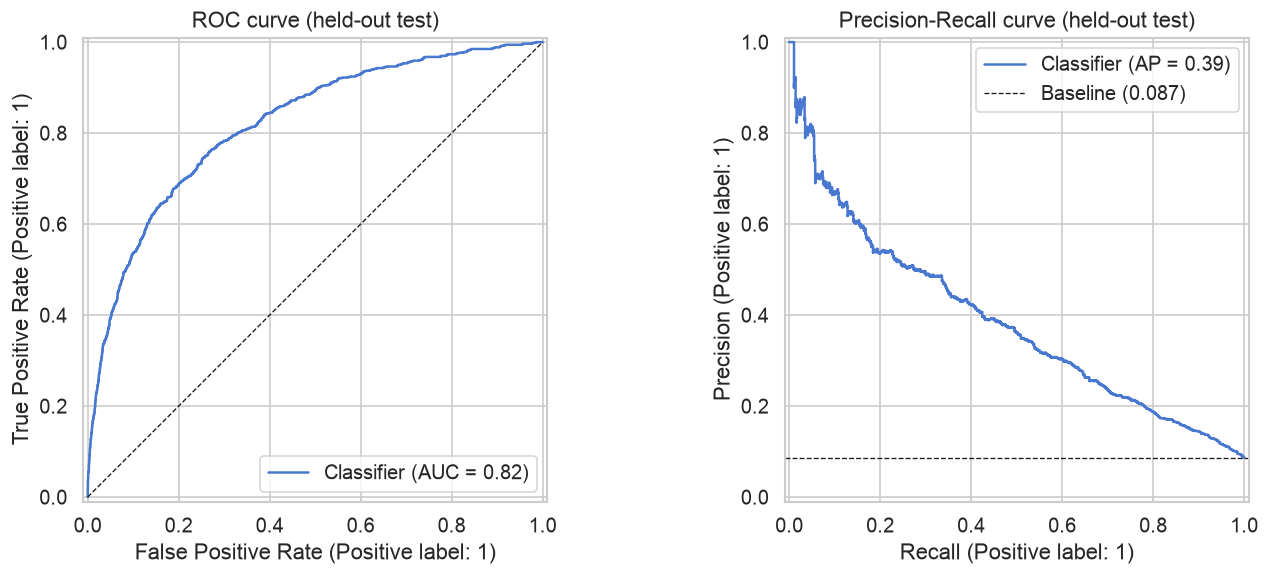

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC curve (held-out test)')

PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=axes[1])
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=0.8, label=f'Baseline ({y_test.mean():.3f})')
axes[1].legend()
axes[1].set_title('Precision-Recall curve (held-out test)')

plt.tight_layout()
plt.show()

## 5. Calibration

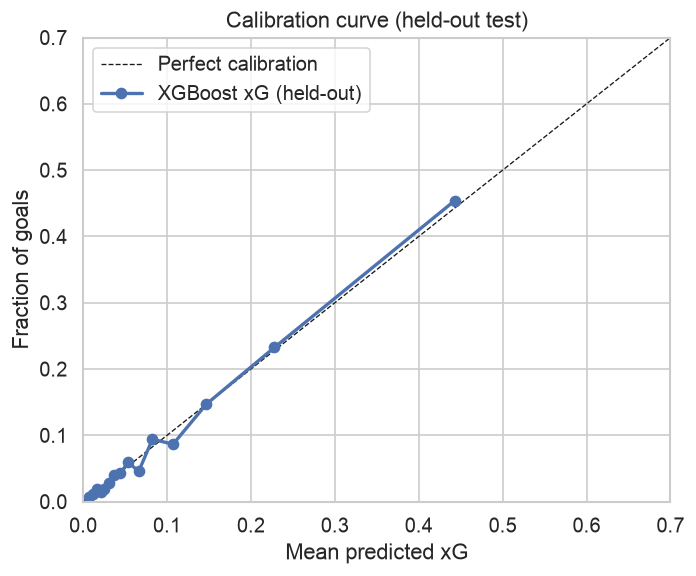

Expected Calibration Error (ECE, held-out test): 0.0049


In [52]:
# Good calibration is the core requirement for xG: a shot assigned 0.3 xG should
# genuinely convert ~30% of the time. Evaluated here on the held-out test set.
fraction_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=15, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
ax.plot(mean_pred, fraction_pos, 'o-', color='#4C72B0', linewidth=2, markersize=6, label='XGBoost xG (held-out)')
ax.set_xlabel('Mean predicted xG')
ax.set_ylabel('Fraction of goals')
ax.set_title('Calibration curve (held-out test)')
ax.legend()
ax.set_xlim(0, 0.7)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

# ECE — Expected Calibration Error (lower is better)
bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(test_proba, bins) - 1
ece = sum(
    (np.sum(bin_ids == b) / len(y_test)) * abs(y_test[bin_ids == b].mean() - test_proba[bin_ids == b].mean())
    for b in range(len(bins) - 1) if np.sum(bin_ids == b) > 0
)
print(f"Expected Calibration Error (ECE, held-out test): {ece:.4f}")

## 6. xG Distribution

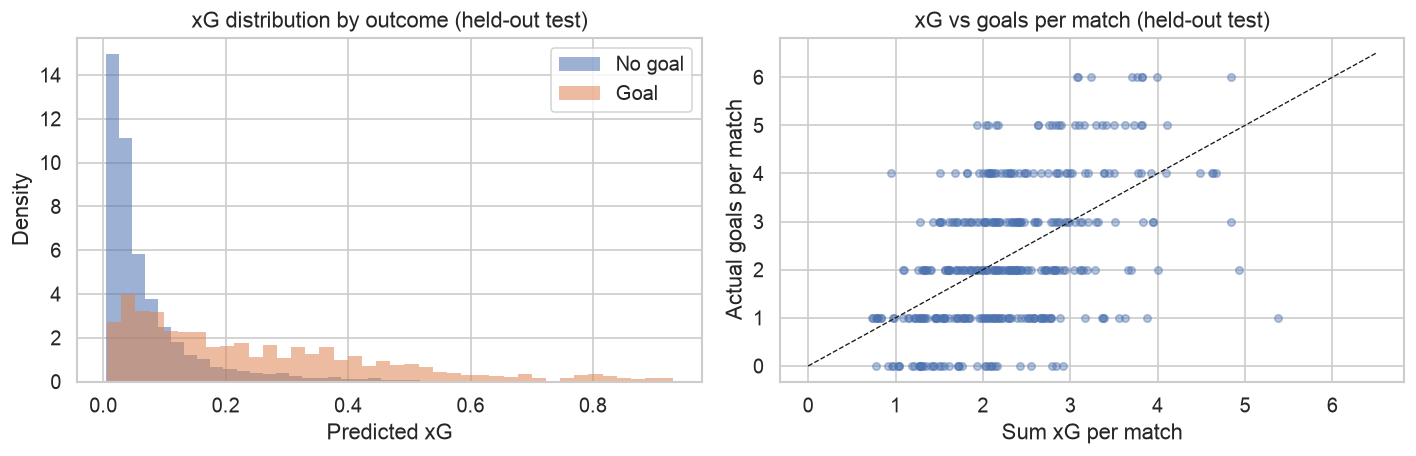

Match-level Pearson r (xG vs goals, held-out test): 0.499


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for outcome, label, color in [(0, 'No goal', '#4C72B0'), (1, 'Goal', '#DD8452')]:
    axes[0].hist(test_proba[y_test == outcome], bins=40, alpha=0.55,
                 label=label, color=color, density=True, edgecolor='none')
axes[0].set_xlabel('Predicted xG')
axes[0].set_ylabel('Density')
axes[0].set_title('xG distribution by outcome (held-out test)')
axes[0].legend()

# Per-match cumulative xG vs actual goals, held-out test matches only
shots_eval = shots_test.copy()
shots_eval['xg'] = test_proba
match_summary = shots_eval.groupby('match_id').agg(
    xG_total=('xg', 'sum'),
    actual_goals=('is_goal', 'sum'),
)
axes[1].scatter(match_summary['xG_total'], match_summary['actual_goals'],
                alpha=0.4, s=20, color='#4C72B0')
lim = max(match_summary[['xG_total', 'actual_goals']].max()) + 0.5
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=0.8)
axes[1].set_xlabel('Sum xG per match')
axes[1].set_ylabel('Actual goals per match')
axes[1].set_title('xG vs goals per match (held-out test)')

plt.tight_layout()
plt.show()

match_corr = match_summary.corr().loc['xG_total', 'actual_goals']
print(f"Match-level Pearson r (xG vs goals, held-out test): {match_corr:.3f}")

## 7. SHAP Feature Importance

In [54]:
# final_model was already fit on the training-competition shots in the
# evaluation cell above; SHAP explains that fitted model over those shots.
X_processed = final_model.named_steps['pre'].transform(X)
X_processed_df = pd.DataFrame(X_processed, columns=ALL_FEATURE_NAMES)

explainer = shap.TreeExplainer(final_model.named_steps['clf'])
shap_values = explainer.shap_values(X_processed_df)

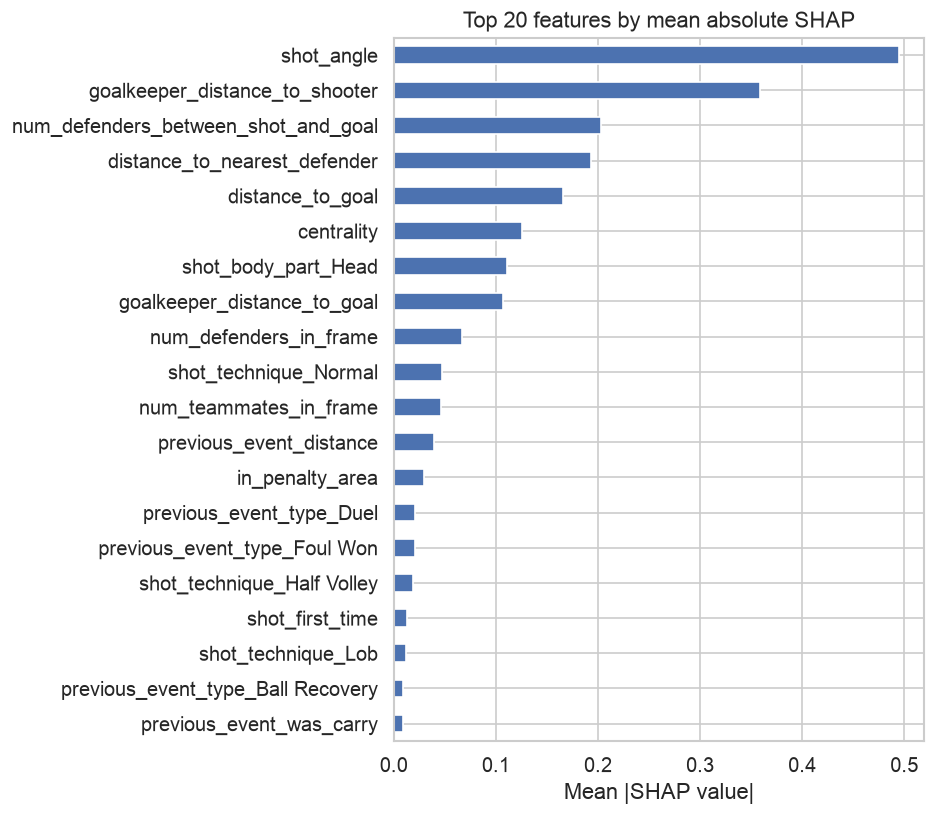

In [55]:
# Mean absolute SHAP — overall feature importance
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=ALL_FEATURE_NAMES,
).sort_values(ascending=True)

top_n = 20
fig, ax = plt.subplots(figsize=(8, 7))
mean_abs_shap.tail(top_n).plot.barh(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top {top_n} features by mean absolute SHAP')
plt.tight_layout()
plt.show()

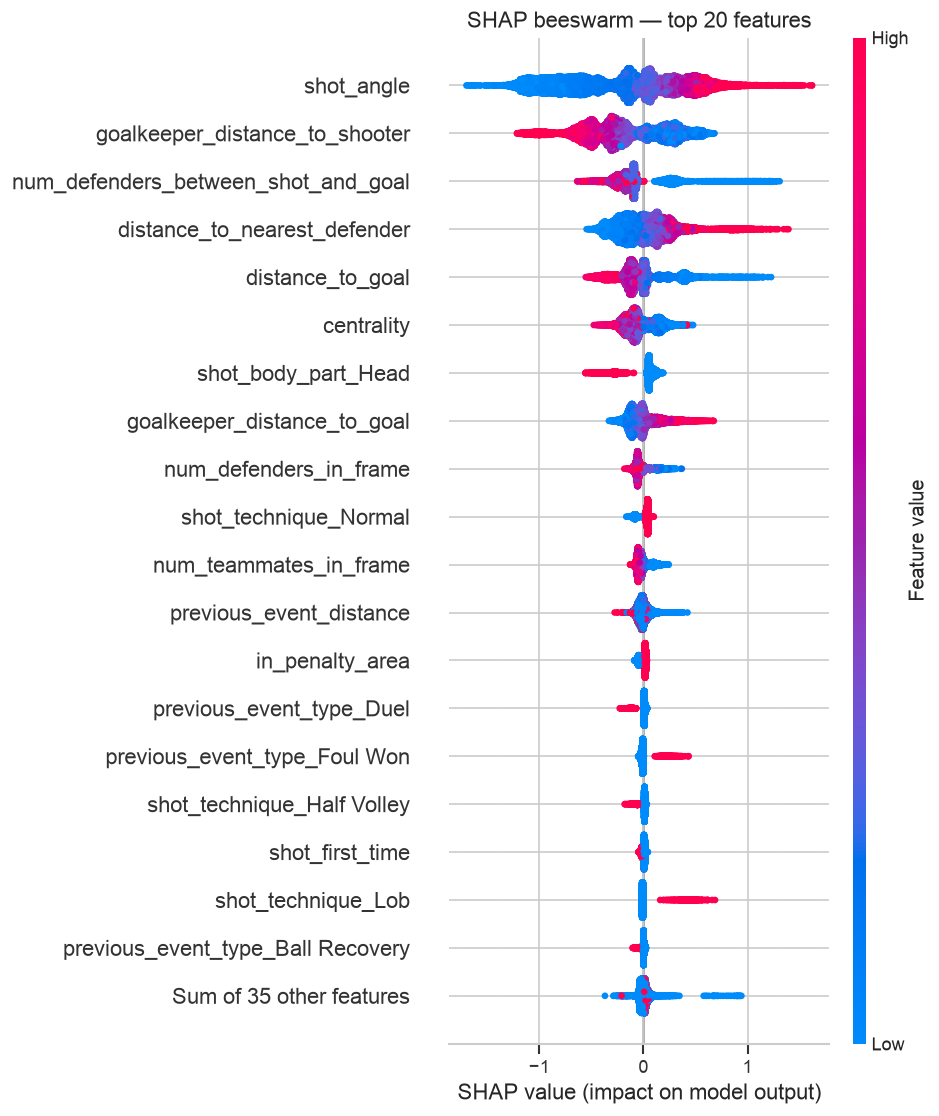

In [56]:
# Beeswarm plot — direction and magnitude of feature effects
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_processed_df.values,
    feature_names=ALL_FEATURE_NAMES,
)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title('SHAP beeswarm — top 20 features')
plt.tight_layout()
plt.show()

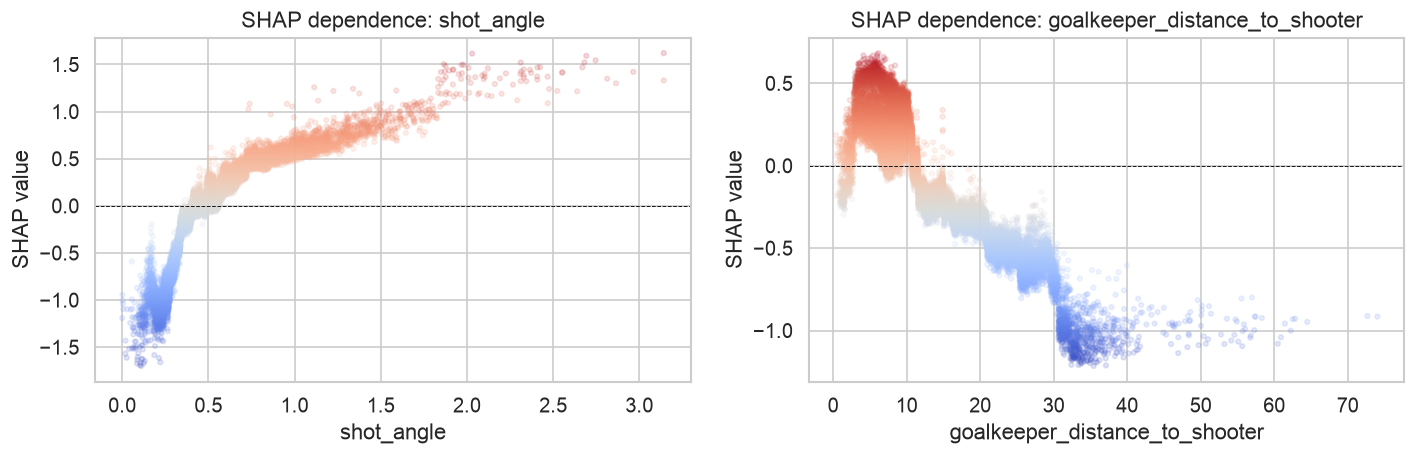

In [57]:
# Dependence plots for the two most important features
top2 = mean_abs_shap.tail(2).index.tolist()[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, top2):
    feat_idx = ALL_FEATURE_NAMES.index(feat)
    ax.scatter(
        X_processed_df[feat], shap_values[:, feat_idx],
        alpha=0.15, s=8, c=shap_values[:, feat_idx], cmap='coolwarm',
    )
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP dependence: {feat}')
plt.tight_layout()
plt.show()

## 8. Results Summary

In [59]:
print("="*45)
print(" XGBoost xG Model — Final Results")
print("="*45)
print(f" Train shots:   {len(shots_train):,} ({train_labels})")
print(f" Test shots:    {len(shots_test):,} ({HOLDOUT_LABEL}, held out)")
print(f" Goal rate:     {y_test.mean():.1%} (held-out test)")
print(f" Features:      {len(ALL_FEATURE_NAMES)} (after encoding)")
print(f" CV folds:      5-fold stratified (training set only)")
print("-"*45)
print(" Training CV (OOF) vs held-out test:")
print(comparison_cv_test.to_string())
print("-"*45)
print(" Held-out test metrics:")
for name, val in metrics.items():
    print(f" {name:<15} {val:.4f}")
print(f" {'ECE':<15} {ece:.4f}")
print("-"*45)
print(f" Top feature:   {mean_abs_shap.index[-1]}")
#print(f" Model saved:   {model_path}")
print("="*45)

 XGBoost xG Model — Final Results
 Train shots:   20,347 (La Liga 2015/16, Champions League 2018/19, Premier League 2015/16, World Cup 2022)
 Test shots:    9,877 (Serie A 2015/16, held out)
 Goal rate:     8.7% (held-out test)
 Features:      54 (after encoding)
 CV folds:      5-fold stratified (training set only)
---------------------------------------------
 Training CV (OOF) vs held-out test:
             Training CV (OOF)  Held-out test (BL 2015/16)
ROC-AUC                 0.8065                      0.8198
Log-loss                0.2585                      0.2324
Brier score             0.0736                      0.0652
---------------------------------------------
 Held-out test metrics:
 ROC-AUC         0.8198
 Log-loss        0.2324
 Brier score     0.0652
 ECE             0.0049
---------------------------------------------
 Top feature:   shot_angle
